**Programmer:** python_scripts (Abhijith Warrier)

**PYTHON SCRIPT TO *DETECT ANOMALIES IN DATA USING ISOLATION FOREST*. ⚡️🚨🤖**

This script demonstrates how to identify **rare or abnormal data points** using **Isolation Forest**, an unsupervised machine learning algorithm widely used in fraud detection, system monitoring, and anomaly analysis.

---

## **📦 Import Required Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_blobs

---

## **🧩 Generate Sample Data (Normal + Anomalies)**

We create a synthetic dataset containing:

- normal data points (clustered)
- anomalous points (randomly scattered)

In [2]:
# Normal data points
X_normal, _ = make_blobs(
    n_samples=300,
    centers=1,
    cluster_std=0.6,
    random_state=42
)

# Anomalous data points
rng = np.random.RandomState(42)
X_anomaly = rng.uniform(low=-6, high=6, size=(20, 2))

# Combine data
X = np.vstack([X_normal, X_anomaly])

df = pd.DataFrame(X, columns=["feature_1", "feature_2"])

---

## **🔍 Visualize Raw Data**

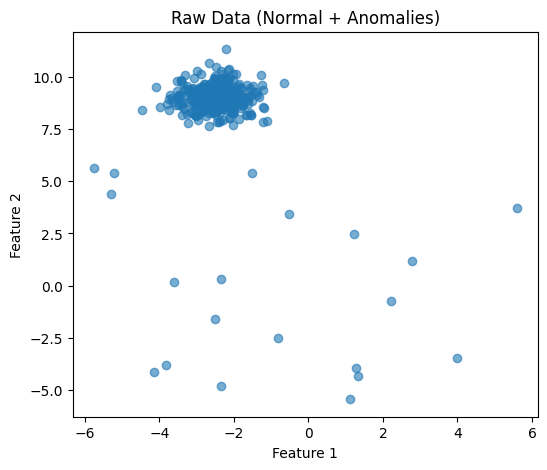

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(df["feature_1"], df["feature_2"], alpha=0.6)
plt.title("Raw Data (Normal + Anomalies)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

---

## **🧠 Train Isolation Forest Model**

Isolation Forest works by **isolating points using random splits** — anomalies get isolated faster.

In [4]:
# Create feature matrix ONCE
X = df[["feature_1", "feature_2"]]

# Train Isolation Forest
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.06,
    random_state=42
)

iso_forest.fit(X)

# Predict anomalies (ONLY using X)
df["anomaly"] = iso_forest.predict(X)
df["anomaly_score"] = iso_forest.decision_function(X)

---

## **🚨 Detect Anomalies**

The model outputs:

- 1 → normal
- 1 → anomaly

In [5]:
df["anomaly"] = iso_forest.predict(X)

---

## **📊 Visualize Detected Anomalies**

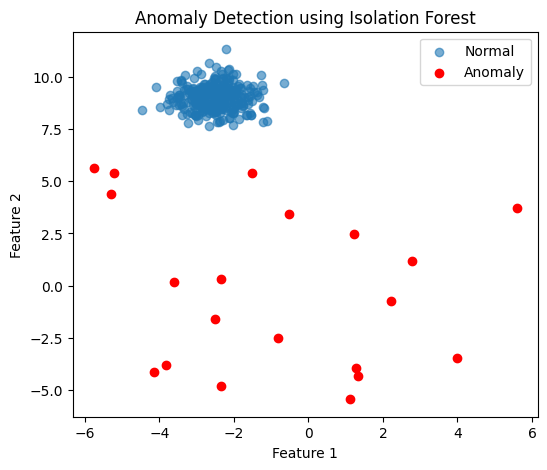

In [6]:
plt.figure(figsize=(6, 5))

normal = df[df["anomaly"] == 1]
anomaly = df[df["anomaly"] == -1]

plt.scatter(
    normal["feature_1"],
    normal["feature_2"],
    label="Normal",
    alpha=0.6
)

plt.scatter(
    anomaly["feature_1"],
    anomaly["feature_2"],
    color="red",
    label="Anomaly"
)

plt.title("Anomaly Detection using Isolation Forest")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

---

## **🔎 Inspect Anomaly Scores (Optional)**

Lower scores indicate stronger anomalies.

In [7]:
df["anomaly_score"] = iso_forest.decision_function(X)

print("Top detected anomalies:")
print(
    df[df["anomaly"] == -1]
    .sort_values("anomaly_score")
    .head()
)

Top detected anomalies:
     feature_1  feature_2  anomaly  anomaly_score
317   5.587584   3.700768       -1      -0.179066
306   3.989312  -3.451931       -1      -0.149111
314   1.108975  -5.442595       -1      -0.116884
301   2.783927   1.183902       -1      -0.110224
319   2.210796  -0.718170       -1      -0.104237


---

## **🧠 Key Takeaways**

1. Anomaly detection is an unsupervised ML problem.
2. Isolation Forest isolates anomalies faster than normal points.
3. No labeled data is required.
4. Visualization makes anomaly detection interpretable.
5. Widely used in fraud detection, monitoring, and security.

---

## **Conclusion**

Isolation Forest provides a powerful and intuitive way to detect anomalies in real-world datasets.

By focusing on **isolation rather than distance**, it scales well and performs effectively even when anomalies are rare.

This makes it a strong addition to the **Saturday ML Spark ⚡️ – Real-World Mini Projects** series.

---